In [76]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
import os
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [77]:
# Select a random image from the dataset
dataset_split = 'train'  # Can be 'train', 'valid', or 'test'
image_dir = os.path.join(dataset_split)

# Get list of images (exclude annotation files)
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
selected_image = random.choice(image_files)

# Load the image
image_path = os.path.join(image_dir, selected_image)
original_img = Image.open(image_path)

print(f"Selected image: {selected_image}")
print(f"Image size: {original_img.size}")
print(f"Image mode: {original_img.mode}")

Selected image: 00000326_jpg.rf.8d4a21c36f181c7d9712249ae4bffe29.jpg
Image size: (640, 640)
Image mode: RGB


In [78]:
from scipy import ndimage
from scipy.signal import fftconvolve
import time

def convert_to_sem_style(img):
    """
    Convert image to Scanning Electron Microscope (SEM) style appearance.
    
    Step 1: Remap colors
      - Black (0, 0, 0) → Gray (124, 124, 124)
      - White (255, 255, 255) → Dark Gray (57, 57, 57)
    Step 2: Apply blur and noise for SEM appearance
    
    Parameters:
    - img: PIL Image (input pattern)
    
    Returns:
    - PIL Image in SEM style with gray tones
    """
    # Convert to grayscale
    img_gray = img.convert('L')
    img_array = np.array(img_gray).astype(float) / 255.0  # Normalize to [0, 1]
    
    # Step 1: Remap colors
    # Black (0) → Gray (124/255 = 0.486)
    # White (1) → Dark Gray (57/255 = 0.224)
    # Linear mapping: output = (1 - input) * (124 - 57) / 255 + 57/255
    # Simplified: output = input * (-67/255) + 124/255
    img_remapped = img_array * (-67/255) + (124/255)
    # This maps: 0 → 124/255, 1 → 57/255
    
    # Step 2: Apply slight Gaussian blur for SEM soft focus
    img_blur = ndimage.gaussian_filter(img_remapped, sigma=0.05)
    
    # Step 3: Add scanning noise (electron beam artifacts)
    noise = np.random.normal(0, 0.015, img_blur.shape)
    img_noisy = img_blur + noise
    img_noisy = np.clip(img_noisy, 0, 1)
    
    # Step 4: Add fine grain texture
    grain_size = 2
    grain = np.random.normal(0, 0.01, (img_noisy.shape[0]//grain_size, img_noisy.shape[1]//grain_size))
    grain_upscaled = ndimage.zoom(grain, grain_size, order=1)
    if grain_upscaled.shape != img_noisy.shape:
        grain_upscaled = grain_upscaled[:img_noisy.shape[0], :img_noisy.shape[1]]
    img_grain = img_noisy + grain_upscaled
    img_grain = np.clip(img_grain, 0, 1)
    
    # Step 5: Slight vignetting
    rows, cols = img_grain.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows / 2, cols / 2
    max_dist = np.sqrt(center_y**2 + center_x**2)
    dist_from_center = np.sqrt((y - center_y)**2 + (x - center_x)**2)
    vignette = 1 - 0.06 * (dist_from_center / max_dist)**2
    img_sem = img_grain * vignette
    
    # Convert back to 8-bit
    img_sem = (img_sem * 255).astype(np.uint8)
    
    return Image.fromarray(img_sem)

def simulate_lithography(img, wavelength=193, na=1.2, defocus=0, dose=1.0, verbose=True):
    """
    Simulate optical lithography process with physical effects.
    
    This simulates how sharp mask features (rectangles, corners) get smoothed
    due to optical diffraction during photolithography exposure.
    
    Parameters:
    - img: PIL Image (layout/mask pattern)
    - wavelength: Exposure wavelength in nm (193nm for ArF)
    - na: Numerical aperture of the lens system (1.2 for immersion)
    - defocus: Defocus amount in wavelength units
    - dose: Exposure dose (0.8-1.2 typical, affects resist threshold)
    - verbose: Print timing information
    
    Returns:
    - PIL Image of pattern after lithography with smoothed corners
    """
    start_time = time.time()
    
    # Convert to grayscale and normalize to [0, 1]
    step_start = time.time()
    img_gray = img.convert('L')
    mask = np.array(img_gray).astype(float) / 255.0
    if verbose:
        print(f"[Step 0] Image conversion: {time.time() - step_start:.3f}s | Image shape: {mask.shape}")
    
    # === Step 1: Mask pattern (no inversion!) ===
    step_start = time.time()
    mask_pattern = mask
    if verbose:
        print(f"[Step 1] Mask pattern: {time.time() - step_start:.3f}s")
    
    # === Step 2: Optical Point Spread Function (PSF) ===
    step_start = time.time()
    resolution_limit = wavelength / (2 * na)
    
    pixel_scale = 10  # nm per pixel
    psf_radius_pixels = int(resolution_limit / pixel_scale)
    psf_radius_pixels = max(5, min(psf_radius_pixels, 50))
    psf_size = psf_radius_pixels * 2 + 1
    
    if verbose:
        print(f"  Resolution limit: {resolution_limit:.2f} nm")
        print(f"  PSF radius: {psf_radius_pixels} pixels")
        print(f"  PSF kernel size: {psf_size}x{psf_size} = {psf_size**2:,} elements")
    
    # Create Airy disk PSF
    y, x = np.ogrid[-psf_radius_pixels:psf_radius_pixels+1, 
                     -psf_radius_pixels:psf_radius_pixels+1]
    r = np.sqrt(x**2 + y**2)
    
    from scipy.special import j1
    v = 2 * np.pi * na * r * pixel_scale / wavelength
    v[v == 0] = 1e-10
    airy = (2 * j1(v) / v) ** 2
    airy = airy / airy.sum()
    
    if defocus != 0:
        defocus_phase = np.pi * na**2 * (r * pixel_scale)**2 * defocus / wavelength**2
        defocus_kernel = np.cos(defocus_phase)
        airy = airy * (1 + 0.5 * defocus_kernel)
        airy = airy / airy.sum()
    
    if verbose:
        print(f"[Step 2] PSF generation: {time.time() - step_start:.3f}s")
    
    # === Step 3: Convolve mask with PSF ===
    step_start = time.time()
    if verbose:
        print(f"  Starting FFT convolution: {mask.shape} * {airy.shape}...")
    aerial_image = fftconvolve(mask_pattern, airy, mode='same')
    aerial_image = np.clip(aerial_image, 0, 1)
    if verbose:
        print(f"[Step 3] FFT Convolution: {time.time() - step_start:.3f}s")
    
    # === Step 4: Apply exposure dose ===
    exposure = aerial_image * dose
    
    # === Step 5: Resist exposure and development ===
    resist_contrast = 5.0
    threshold = 0.5
    developed_resist = 1 / (1 + np.exp(-resist_contrast * (exposure - threshold)))
    
    # === Step 6: Add process variations ===
    ler_noise = np.random.normal(0, 0.02, developed_resist.shape)
    developed_resist = np.clip(developed_resist + ler_noise, 0, 1)
    
    defect_probability = 0.001
    defect_mask = np.random.random(developed_resist.shape) < defect_probability
    developed_resist[defect_mask] = np.random.uniform(0.3, 0.7, np.sum(defect_mask))
    
    # === Step 7: Convert to 8-bit image ===
    final_pattern = developed_resist * 255
    final_pattern = final_pattern.astype(np.uint8)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"TOTAL TIME: {time.time() - start_time:.3f}s")
        print(f"{'='*60}\n")
    
    return Image.fromarray(final_pattern)

# Step 1: Convert to SEM style
print("Step 1: Converting to SEM (Electron Microscope) style...")
print("Color remapping:")
print("  Black (0, 0, 0) → Gray (124, 124, 124)")
print("  White (255, 255, 255) → Dark Gray (57, 57, 57)")
print("Then applying blur and noise...")
sem_img = convert_to_sem_style(original_img)
print("SEM conversion complete!\n")

# Step 2: Apply lithography simulation
print("Step 2: Running lithography simulation...")
print("Parameters:")
print("  - Wavelength: 193 nm (ArF excimer laser)")
print("  - Numerical Aperture: 1.2 (Immersion lithography)")
print("  - Dose: 1.0")
print("Effect: Very minimal blur - Sharp corners → Slightly smoothed/rounded corners")
print()

wafer_img = simulate_lithography(sem_img, wavelength=193, na=1.2, defocus=0, dose=1.0)

print("Complete! Generated 3 stages:")
print("  1. Original PCB image")
print("  2. SEM-style conversion (Black→124, White→57, then blurred)")
print("  3. SEM + Lithography blur")

Step 1: Converting to SEM (Electron Microscope) style...
Color remapping:
  Black (0, 0, 0) → Gray (124, 124, 124)
  White (255, 255, 255) → Dark Gray (57, 57, 57)
Then applying blur and noise...
SEM conversion complete!

Step 2: Running lithography simulation...
Parameters:
  - Wavelength: 193 nm (ArF excimer laser)
  - Numerical Aperture: 1.2 (Immersion lithography)
  - Dose: 1.0
Effect: Very minimal blur - Sharp corners → Slightly smoothed/rounded corners

[Step 0] Image conversion: 0.002s | Image shape: (640, 640)
[Step 1] Mask pattern: 0.000s
  Resolution limit: 80.42 nm
  PSF radius: 8 pixels
  PSF kernel size: 17x17 = 289 elements
[Step 2] PSF generation: 0.000s
  Starting FFT convolution: (640, 640) * (17, 17)...
[Step 3] FFT Convolution: 0.014s

TOTAL TIME: 0.041s

Complete! Generated 3 stages:
  1. Original PCB image
  2. SEM-style conversion (Black→124, White→57, then blurred)
  3. SEM + Lithography blur


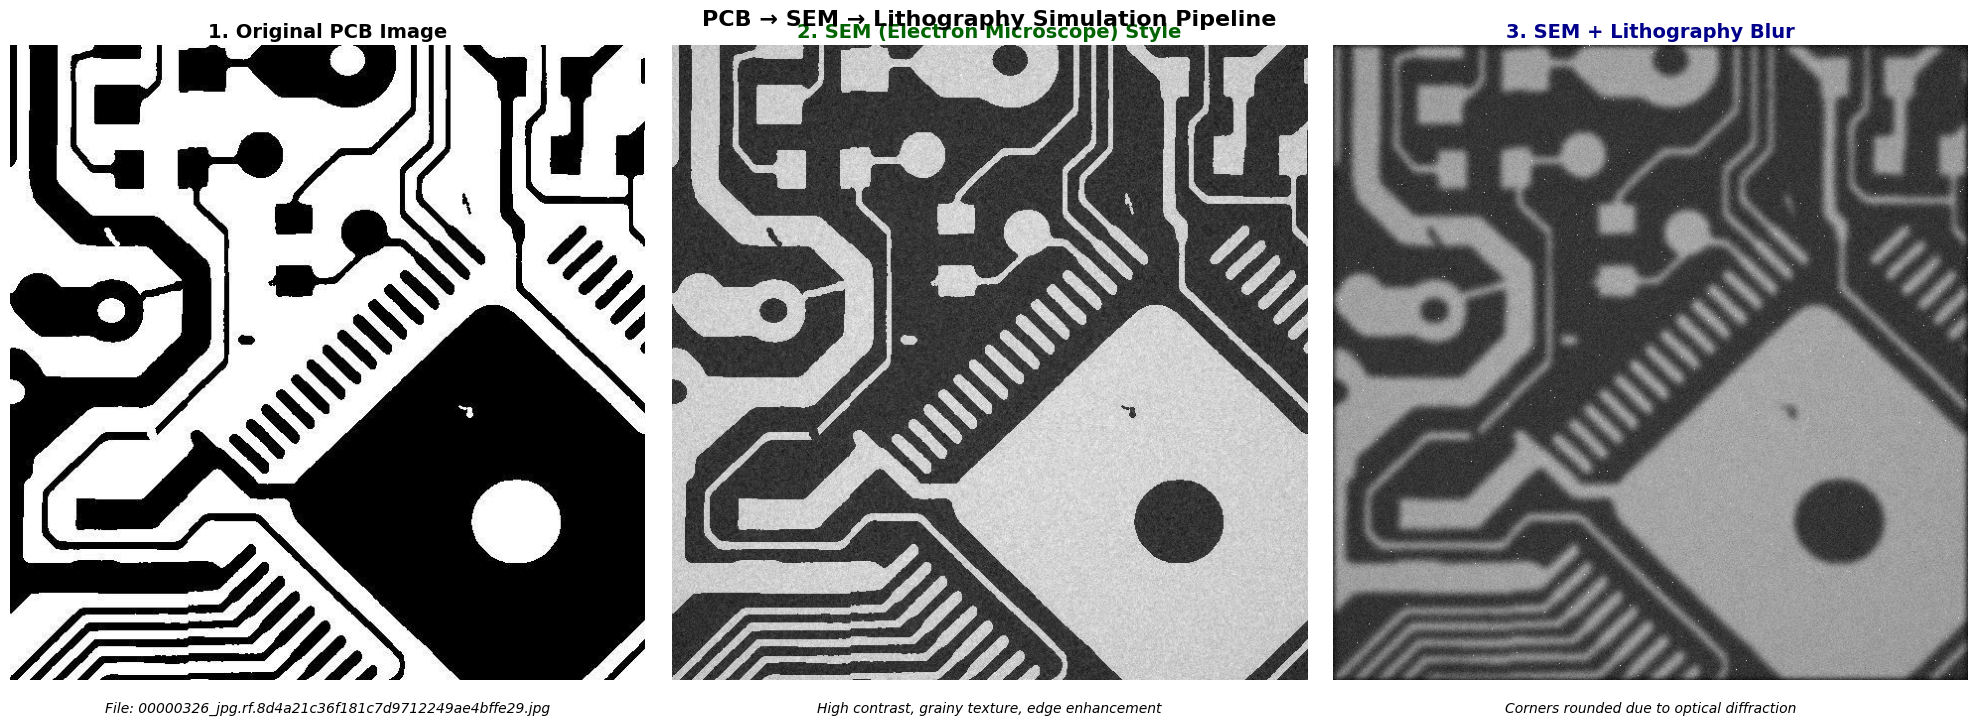

In [ ]:
# Display 3-stage transformation: Original → SEM → SEM + Lithography
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# Original PCB image
ax1.imshow(original_img)
ax1.set_title('1. Original PCB Image', fontsize=14, fontweight='bold')
ax1.axis('off')
ax1.text(0.5, -0.05, f'File: {selected_image}', 
         ha='center', transform=ax1.transAxes, fontsize=10, style='italic')

# SEM-style conversion
ax2.imshow(sem_img, cmap='gray')
ax2.set_title('2. SEM (Electron Microscope) Style', 
              fontsize=14, fontweight='bold', color='darkgreen')
ax2.axis('off')
ax2.text(0.5, -0.05, 'High contrast, grainy texture, edge enhancement', 
         ha='center', transform=ax2.transAxes, fontsize=10, style='italic')

# After lithography simulation
ax3.imshow(wafer_img, cmap='gray')
ax3.set_title('3. SEM + Lithography Blur', 
              fontsize=14, fontweight='bold', color='darkblue')
ax3.axis('off')
ax3.text(0.5, -0.05, 'Corners rounded due to optical diffraction', 
         ha='center', transform=ax3.transAxes, fontsize=10, style='italic')

plt.suptitle('PCB → SEM → Lithography Simulation Pipeline', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## PCB to Semiconductor Wafer Lithography Simulation

This notebook demonstrates a **physics-based optical lithography simulation** that transforms PCB defect images into realistic semiconductor wafer patterns using the actual physics of photolithography.

### Physical Lithography Process Simulated

1. **Mask Transmission** - PCB image treated as photomask (binary transmission)
2. **Optical Diffraction** - Airy disk Point Spread Function based on wavelength (λ) and numerical aperture (NA)
3. **Aerial Image Formation** - Convolution of mask with PSF simulates light diffraction through lens
4. **Exposure Dose** - Controls the intensity of light reaching the photoresist
5. **Photoresist Response** - Sigmoid model simulates chemical development threshold
6. **Process Variations** - Adds line edge roughness (LER) and random particle defects

### Lithography Parameters

- **Wavelength**: 193 nm (ArF excimer laser - deep UV)
- **Numerical Aperture (NA)**: 0.85 (typical for advanced lithography)
- **Resolution Limit**: λ/(2·NA) ≈ 113 nm
- **Resist Model**: Positive photoresist with sigmoid contrast curve
- **Defects**: Line edge roughness (LER) and particle contamination

### Physical Effects Included

✓ **Optical Proximity Effects (OPE)** - Features affect neighboring patterns through diffraction  
✓ **Diffraction Blur** - Small features lose sharpness due to wave nature of light  
✓ **Resist Threshold** - Non-linear chemical development response  
✓ **Line Edge Roughness** - Stochastic molecular-scale variations  
✓ **Process Defects** - Random particles causing micro-bridging or breaks

### Why This Matters

Real semiconductor lithography is **NOT** a simple mask projection - it involves:
- Wave optics (diffraction, interference)
- Chemical processes (photoresist exposure/development)
- Process variations (roughness, defects)

This simulation captures these physical effects, creating realistic wafer patterns that show actual lithographic artifacts like corner rounding, line width variations, and proximity effects.

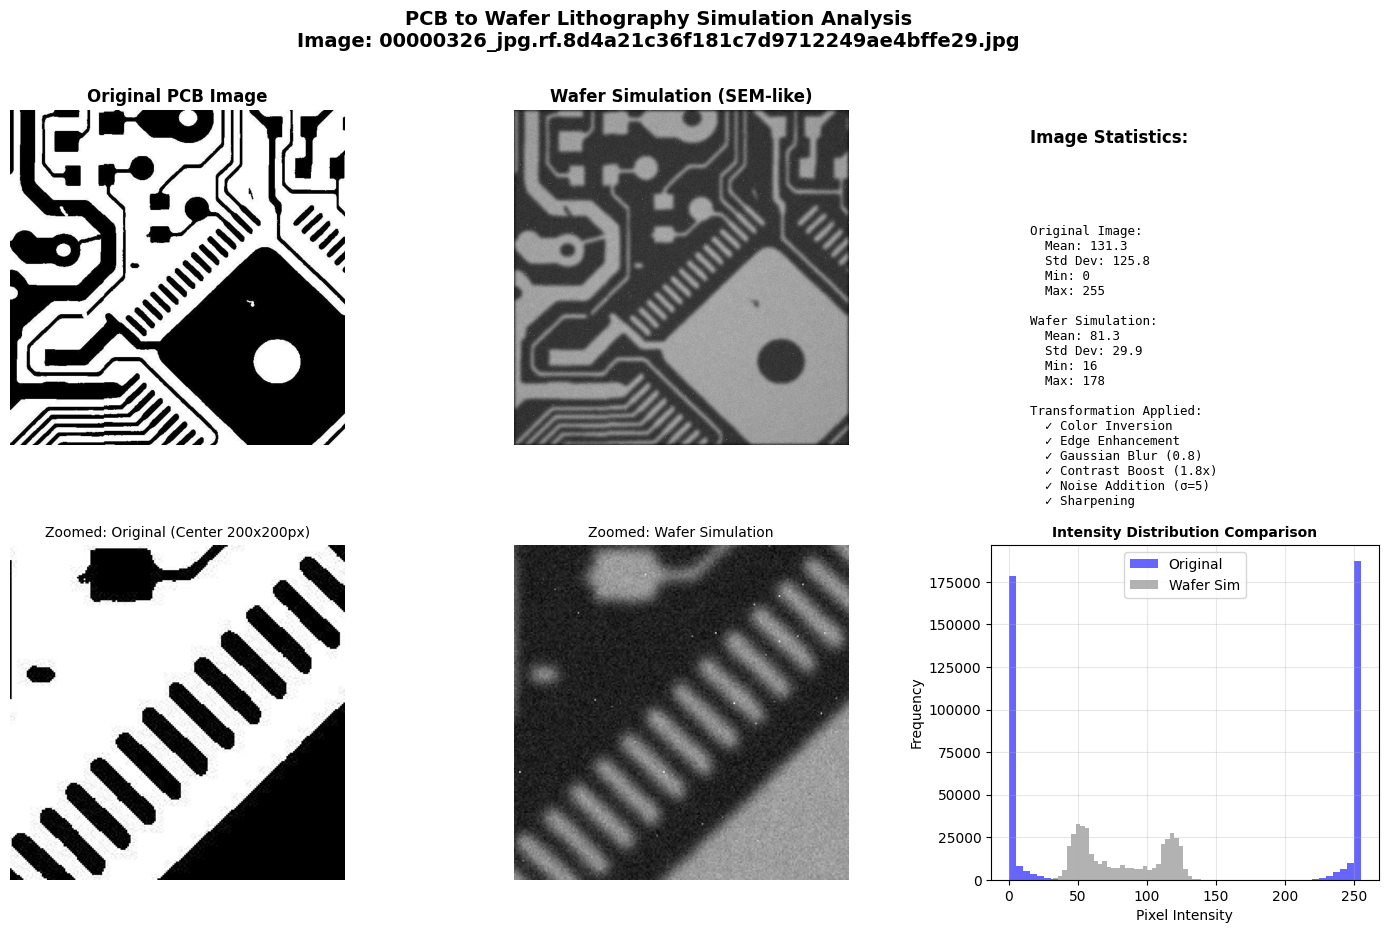

In [80]:
# Create a more detailed comparison with zoomed views
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Original full image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(original_img)
ax1.set_title('Original PCB Image', fontsize=12, fontweight='bold')
ax1.axis('off')

# Wafer simulation full image
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(wafer_img, cmap='gray')
ax2.set_title('Wafer Simulation (SEM-like)', fontsize=12, fontweight='bold')
ax2.axis('off')

# Statistics comparison
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.text(0.1, 0.9, 'Image Statistics:', fontsize=12, fontweight='bold', transform=ax3.transAxes)

original_array = np.array(original_img.convert('L'))
wafer_array = np.array(wafer_img)

stats_text = f"""
Original Image:
  Mean: {original_array.mean():.1f}
  Std Dev: {original_array.std():.1f}
  Min: {original_array.min()}
  Max: {original_array.max()}

Wafer Simulation:
  Mean: {wafer_array.mean():.1f}
  Std Dev: {wafer_array.std():.1f}
  Min: {wafer_array.min()}
  Max: {wafer_array.max()}
  
Transformation Applied:
  ✓ Color Inversion
  ✓ Edge Enhancement
  ✓ Gaussian Blur (0.8)
  ✓ Contrast Boost (1.8x)
  ✓ Noise Addition (σ=5)
  ✓ Sharpening
"""

ax3.text(0.1, 0.7, stats_text, fontsize=9, family='monospace', 
         transform=ax3.transAxes, verticalalignment='top')

# Zoomed crop - center region
crop_size = 200
h, w = original_img.size
center_x, center_y = w // 2, h // 2
crop_box = (center_x - crop_size//2, center_y - crop_size//2, 
            center_x + crop_size//2, center_y + crop_size//2)

original_crop = original_img.crop(crop_box)
wafer_crop = wafer_img.crop(crop_box)

ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(original_crop)
ax4.set_title(f'Zoomed: Original (Center {crop_size}x{crop_size}px)', fontsize=10)
ax4.axis('off')

ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(wafer_crop, cmap='gray')
ax5.set_title(f'Zoomed: Wafer Simulation', fontsize=10)
ax5.axis('off')

# Histogram comparison
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(original_array.ravel(), bins=50, alpha=0.6, label='Original', color='blue')
ax6.hist(wafer_array.ravel(), bins=50, alpha=0.6, label='Wafer Sim', color='gray')
ax6.set_xlabel('Pixel Intensity', fontsize=10)
ax6.set_ylabel('Frequency', fontsize=10)
ax6.set_title('Intensity Distribution Comparison', fontsize=10, fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)

plt.suptitle(f'PCB to Wafer Lithography Simulation Analysis\nImage: {selected_image}', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()